In [3]:
# [셀 1] PyTorch 설치 (필요한 경우)
# !pip install torch --quiet

In [13]:
# [셀 2] 라이브러리 임포트 및 데이터셋 정의
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
  
# XOR 데이터셋
class XORDataset(Dataset):
    def __init__(self):
        # XOR 진리표: (x1, x2) -> y
        self.data = [
            (torch.tensor([0.0, 0.0]), torch.tensor([0.0])),
            (torch.tensor([0.0, 1.0]), torch.tensor([1.0])),
            (torch.tensor([1.0, 0.0]), torch.tensor([1.0])),
            (torch.tensor([1.0, 1.0]), torch.tensor([0.0])),
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [8]:
# [셀 3] 모델 정의 (MLP)
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()  # 출력: 0~1 확률
        )

    def forward(self, x):
        return self.net(x)

In [9]:
# [셀 4] 학습 설정 및 학습 루프
dataset = XORDataset()
loader = DataLoader(dataset, batch_size=4, shuffle=True)
model = XORNet()
criterion = nn.BCELoss()  # Binary Cross-Entropy
optimizer = optim.Adam(model.parameters(), lr=0.1)

epochs = 5000
loss_history = []

for epoch in range(epochs):
    total_loss = 0.0
    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x_batch.size(0)
    avg_loss = total_loss / len(dataset)
    loss_history.append(avg_loss)
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

Epoch 500/5000, Loss: 0.000602
Epoch 1000/5000, Loss: 0.000189
Epoch 1500/5000, Loss: 0.000092
Epoch 2000/5000, Loss: 0.000054
Epoch 2500/5000, Loss: 0.000034
Epoch 3000/5000, Loss: 0.000023
Epoch 3500/5000, Loss: 0.000016
Epoch 4000/5000, Loss: 0.000012
Epoch 4500/5000, Loss: 0.000009
Epoch 5000/5000, Loss: 0.000006


/tmp/ipykernel_118569/389693242.py:8: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_118569/389693242.py:8: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_118569/389693242.py:8: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_118569/389693242.py:8: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_118569/389693242.py:8: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_118569/389693242.py:8: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/loveiori/workspace/ai-lectures/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54617 (\N{H

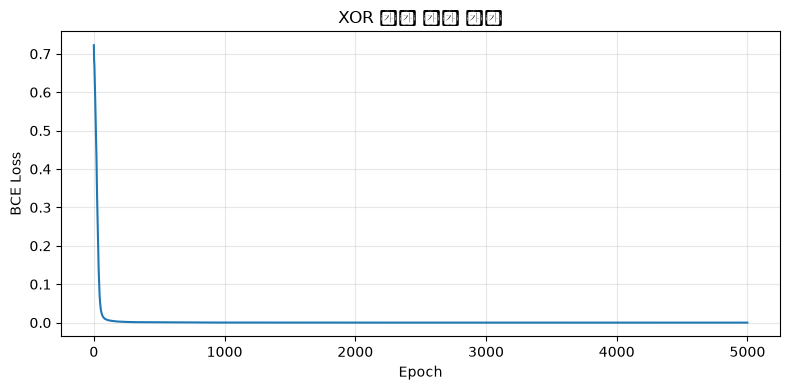

In [10]:
# [셀 5] 학습 손실 시각화
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("XOR 학습 손실 곡선")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# [셀 6] 평가: XOR 진리표 전체에 대해 예측 확인
model.eval()
print("\nXOR 예측 결과:")
print("x1\tx2\t실제\t예측(확률)\t예측(클래스)")
with torch.no_grad():
    for x1 in [0.0, 1.0]:
        for x2 in [0.0, 1.0]:
            x = torch.tensor([[x1, x2]], dtype=torch.float32)
            y_true = int(x1 != x2)  # XOR: 다르면 1, 같으면 0
            y_prob = model(x).item()
            y_pred = 1 if y_prob >= 0.5 else 0
            print(f"{x1:.0f}\t{x2:.0f}\t{y_true}\t{y_prob:.4f}\t\t{y_pred}")


XOR 예측 결과:
x1	x2	실제	예측(확률)	예측(클래스)
0	0	0	0.0000		0
0	1	1	1.0000		1
1	0	1	1.0000		1
1	1	0	0.0000		0


/tmp/ipykernel_118569/976274325.py:21: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_118569/976274325.py:21: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_118569/976274325.py:21: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_118569/976274325.py:21: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/loveiori/workspace/ai-lectures/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/loveiori/workspace/ai-lectures/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) De

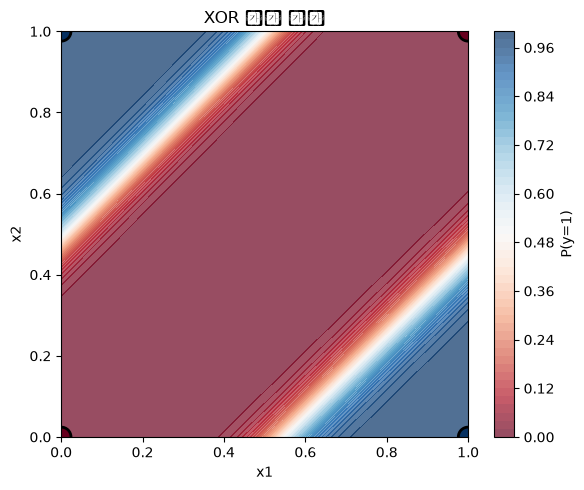

In [12]:
# [셀 7] 결정 경계 시각화 (선택)
# 입력 공간 전체에 대한 예측 확률을 히트맵으로 표시
xx, yy = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

model.eval()
with torch.no_grad():
    probs = model(grid).numpy().reshape(100, 100)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, probs, levels=50, cmap='RdBu', alpha=0.7)
plt.colorbar(label='P(y=1)')
# 실제 데이터 포인트 표시
points = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
labels = np.array([0, 1, 1, 0])
plt.scatter(points[:, 0], points[:, 1], c=labels, cmap='RdBu',
            edgecolors='k', s=200, linewidth=2)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('XOR 결정 경계')
plt.tight_layout()
plt.show()

In [ ]:
# [셀 8] 정확도 및 손실 최종 출력
model.eval()
correct = 0
total_loss = 0.0
with torch.no_grad():
    for x, y in dataset:
        y_prob = model(x.unsqueeze(0)).item()
        y_pred = 1 if y_prob >= 0.5 else 0
        if y_pred == int(y.item()):
            correct += 1
        total_loss += criterion(model(x.unsqueeze(0)), y.unsqueeze(0)).item()

print(f"\n최종 정확도: {correct}/{len(dataset)} ({100*correct/len(dataset):.1f}%)")
print(f"평균 손실: {total_loss/len(dataset):.6f}")


최종 정확도: 2/4 (50.0%)
평균 손실: 0.693147
